In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/trilytics-clean2/train_clean (1).csv


In [ ]:
train_df=pd.read_csv('/kaggle/input/trilytics-clean2/train_clean (1).csv')
train_df=train_df.drop(columns='Unnamed: 0',axis=1)
train_df.head()

,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,K022_Village_category_based_on_Agri_parameters__Good__Average__Poor_,K022_Nearest_Mandi_Name,...,perc_of_pop_living_in_hh_electricity_log,perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms_log,mat_roof_Metal_GI_Asbestos_sheets_log,perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k_log,K022_Total_Geographical_Area__in_Hectares___log,K022_Net_Agri_area__in_Ha___log,_Night_light_index_log,_Land_Holding_Index_source__Total_Agri_Area__no_of_people__log,_Road_density__Km__SqKm__log,Target_Variable_Total_Income_log
0,MADHYA PRADESH,CENTRAL,M,BARELI,464668,RAISEN,Seoni,M,Poor,Gotegaon,...,4.608166,1.169381,0.553885,2.778819,6.574657,6.183324,0.667829,0.570980,0.000000,14.122996
1,BIHAR,EAST,M,BANDRA,848125,MUZAFFARPUR,Namapur,M,Poor,Chandur(Mungodu),...,4.573163,1.562346,2.195000,1.264127,7.339531,6.975423,0.678034,0.371564,0.000000,13.601328
2,MADHYA PRADESH,CENTRAL,M,MALHARGARH,458556,MANDSAUR,Billaud,M,Average,Mandsaur,...,4.614130,1.396245,2.252344,2.207175,7.249151,6.903175,0.667829,0.506818,0.000000,13.122365
3,MAHARASHTRA,WEST,M,RENAPUR,413527,LATUR,Renapur,M,Average,Renapur,...,4.586191,2.371178,4.347823,2.808800,8.264343,8.095016,0.683097,0.215111,1.249902,13.232116
4,MADHYA PRADESH,CENTRAL,F,KHURAI,470117,SAGAR,Singhpur,M,Poor,Javera,...,4.601162,1.449269,0.974560,2.262804,6.442365,5.933014,0.678034,0.190620,0.000000,13.592368


In [ ]:
train_df['Zipcode']=train_df['Zipcode'].astype('object')
train_df.dtypes

State                                                                              object
REGION                                                                             object
SEX                                                                                object
CITY                                                                               object
Zipcode                                                                            object
DISTRICT                                                                           object
VILLAGE                                                                            object
MARITAL_STATUS                                                                     object
K022_Village_category_based_on_Agri_parameters__Good__Average__Poor_               object
K022_Nearest_Mandi_Name                                                            object
K022_Proximity_to_nearest_mandi__Km_                                              float64
K022_Proxi

In [ ]:
high_cardinal=['Zipcode','CITY', 'DISTRICT', 'VILLAGE','K022_Nearest_Mandi_Name']
cat_col = list(train_df.select_dtypes(include=['object']).columns)
num_col = list(train_df.select_dtypes(include=['number']).columns)
print(len(cat_col), len(num_col))

31 75


In [ ]:
from sklearn.model_selection import train_test_split

target='Target_Variable_Total_Income_log'

X = train_df.drop(columns=[target])
y = train_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import sklearn
import category_encoders

print("scikit-learn:", sklearn.__version__)
print("category_encoders:", category_encoders.__version__)

scikit-learn: 1.2.2
category_encoders: 2.7.0


In [ ]:
from category_encoders import TargetEncoder

for col in high_cardinal:
    te = TargetEncoder()
    X_train[col] = te.fit_transform(X_train[col], y_train)
    X_val[col] = te.transform(X_val[col])

In [ ]:
from sklearn.preprocessing import LabelEncoder

low_card_cat = [col for col in cat_col if col not in high_cardinal]
for col in low_card_cat:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))

from sklearn.preprocessing import StandardScaler
num_feat=[col for col in num_col if col != target]
scaler = StandardScaler()
X_train[num_feat] = scaler.fit_transform(X_train[num_feat])
X_val[num_feat] = scaler.transform(X_val[num_feat])

In [ ]:
X_train.dtypes

State                                                                               int64
REGION                                                                              int64
SEX                                                                                 int64
CITY                                                                              float64
Zipcode                                                                           float64
DISTRICT                                                                          float64
VILLAGE                                                                           float64
MARITAL_STATUS                                                                      int64
K022_Village_category_based_on_Agri_parameters__Good__Average__Poor_                int64
K022_Nearest_Mandi_Name                                                           float64
K022_Proximity_to_nearest_mandi__Km_                                              float64
K022_Proxi

In [ ]:
!pip install autofeat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 9.2 MB/s eta 0:00:00


In [ ]:
from autofeat import AutoFeatRegressor

# ↓ Reduce the complexity:
afr = AutoFeatRegressor(
    feateng_steps=1,        # Keep it 1 to avoid memory blowup       # Select only top 100 generated features
    n_jobs=-1,              # Parallel if you can afford it
    verbose=1,
    max_gb=15
)

X_train_num = X_train[num_feat].copy()
X_val_num = X_val[num_feat].copy()

X_train_cat = X_train[cat_col].copy()
X_val_cat = X_val[cat_col].copy()

X_train_auto = afr.fit_transform(X_train_num, y_train)

# Step 4: Transform validation numeric data using the same pipeline
X_val_auto = afr.transform(X_val_num)

# Step 5: Combine back with categorical features (already encoded)
X_val_af = pd.concat([
    X_val_auto.reset_index(drop=True),
    X_val_cat.reset_index(drop=True)
], axis=1)


[featsel] Scaling data.../             74 features transformeddone.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   16.2s remaining:   24.3s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   16.8s remaining:   11.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   22.2s finished


In [ ]:
len(X_train_af.columns)

151

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
import optuna

final_results = {}
best_params={}
def tune_xgb(X_train, y_train, X_test, y_test, n_trials=50):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "n_jobs": -1,
            "random_state": 42
        }
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("XGBoost Best Params:", study.best_params)
    final_results['XGBoost'] = study.best_value
    best_params['xgb']=study.best_value

def tune_lgbm(X_train, y_train, X_test, y_test, n_trials=50):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "n_jobs": -1,
            "random_state": 42,
            "verbose":-1
        }
        model = LGBMRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("LightGBM Best Params:", study.best_params)
    final_results['LightGBM'] = study.best_value
    best_params['lgbm']=study.best_value

tune_lgbm(X_train_af, y_train,X_val_af,y_val)

print("\n=== Final tuned MAPEs ===")
for model, mape in final_results.items():
    print(f"{model}: {mape:.4f}")


[I 2025-07-27 10:28:18,021] A new study created in memory with name: no-name-02c5b715-30d2-442c-a42c-dda7af498419
[I 2025-07-27 10:28:30,621] Trial 0 finished with value: 0.21875829723874296 and parameters: {'n_estimators': 857, 'max_depth': 6, 'learning_rate': 0.012509443232163284, 'num_leaves': 54, 'subsample': 0.7117982211761619, 'colsample_bytree': 0.6435949365951956, 'reg_alpha': 4.150455371644684, 'reg_lambda': 0.09613355057909778}. Best is trial 0 with value: 0.21875829723874296.
[I 2025-07-27 10:28:44,483] Trial 1 finished with value: 0.21175112339275987 and parameters: {'n_estimators': 766, 'max_depth': 5, 'learning_rate': 0.2652960210885038, 'num_leaves': 38, 'subsample': 0.6186987139566353, 'colsample_bytree': 0.9260907751003671, 'reg_alpha': 2.8000608716589515, 'reg_lambda': 2.962005498372891}. Best is trial 1 with value: 0.21175112339275987.
[I 2025-07-27 10:28:57,057] Trial 2 finished with value: 0.20776883032012397 and parameters: {'n_estimators': 506, 'max_depth': 8, 'l

LightGBM Best Params: {'n_estimators': 1354, 'max_depth': 12, 'learning_rate': 0.024803865000364047, 'num_leaves': 97, 'subsample': 0.890477661669688, 'colsample_bytree': 0.6773272054061491, 'reg_alpha': 0.7632670376499324, 'reg_lambda': 0.6036696385371743}

=== Final tuned MAPEs ===
LightGBM: 0.2015


In [ ]:
lgbm_bestparams={'n_estimators': 1354, 'max_depth': 12, 'learning_rate': 0.024803865000364047, 'num_leaves': 97, 'subsample': 0.890477661669688, 'colsample_bytree': 0.6773272054061491, 'reg_alpha': 0.7632670376499324, 'reg_lambda': 0.6036696385371743}

model = LGBMRegressor(**lgbm_bestparams)
model.fit(X_train_af,y_train)

LGBMRegressor(colsample_bytree=0.6773272054061491,
              learning_rate=0.024803865000364047, max_depth=12,
              n_estimators=1354, num_leaves=97, reg_alpha=0.7632670376499324,
              reg_lambda=0.6036696385371743, subsample=0.890477661669688)

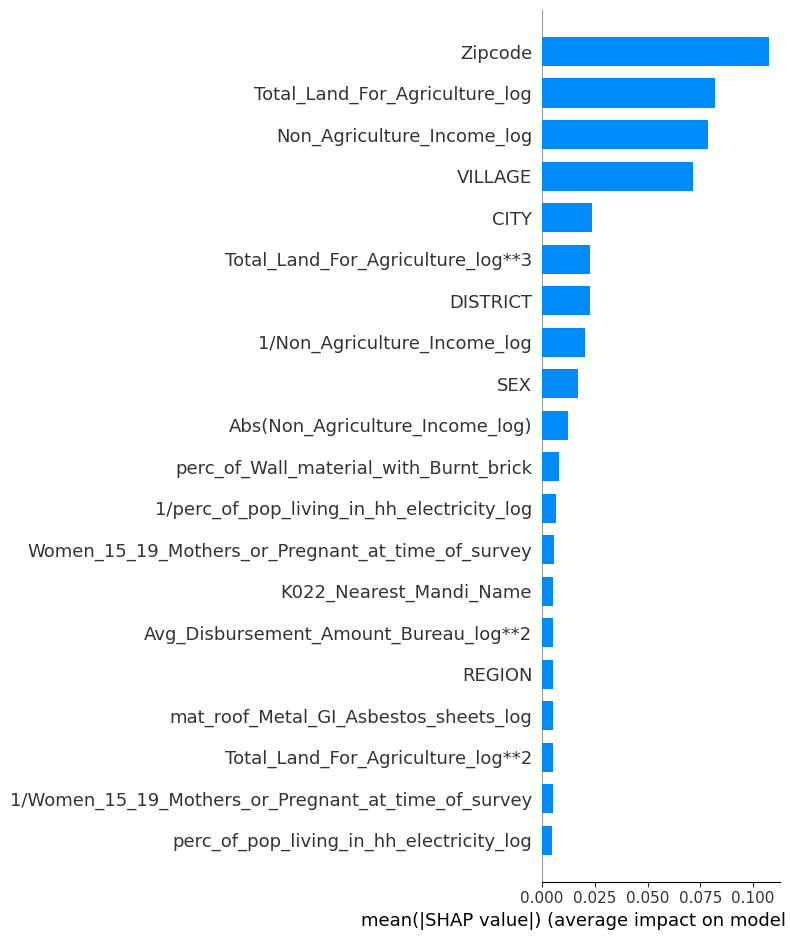

ValueError: Could not find feature named: feature_name

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_af)
shap.summary_plot(shap_values, X_val_af, plot_type="bar")

In [ ]:
shap_df = pd.DataFrame(shap_values, columns=X_val_af.columns)

# Calculate mean absolute SHAP value per feature
feature_importance = shap_df.abs().mean().sort_values(ascending=False)

# Convert to DataFrame for better display
feature_importance_df = feature_importance.reset_index()
feature_importance_df.columns = ['Feature', 'Mean |SHAP|']

print(feature_importance_df)

                                               Feature  Mean |SHAP|
0                                              Zipcode     0.107360
1                       Total_Land_For_Agriculture_log     0.081817
2                           Non_Agriculture_Income_log     0.078836
3                                              VILLAGE     0.071327
4                                                 CITY     0.023924
5                    Total_Land_For_Agriculture_log**3     0.022746
6                                             DISTRICT     0.022707
7                         1/Non_Agriculture_Income_log     0.020389
8                                                  SEX     0.016934
9                      Abs(Non_Agriculture_Income_log)     0.012542
10              perc_of_Wall_material_with_Burnt_brick     0.007964
11          1/perc_of_pop_living_in_hh_electricity_log     0.006473
12   Women_15_19_Mothers_or_Pregnant_at_time_of_survey     0.005679
13                             K022_Nearest_Mand

In [ ]:
# Calculate total importance
total_importance = feature_importance_df['Mean |SHAP|'].sum()

# Calculate cumulative importance
feature_importance_df['Cumulative Importance'] = feature_importance_df['Mean |SHAP|'].cumsum() / total_importance

# Set your threshold (e.g., 95%)
threshold = 0.95

# Select features to keep
features_to_keep = feature_importance_df[feature_importance_df['Cumulative Importance'] <= threshold]['Feature'].tolist()

# Optional: force include the feature just beyond the threshold
if len(features_to_keep) < len(feature_importance_df):
    features_to_keep.append(feature_importance_df.iloc[len(features_to_keep)]['Feature'])

feature_importance_df['Keep'] = feature_importance_df['Feature'].isin(features_to_keep)

n_kept = feature_importance_df['Keep'].sum()
n_removed = (~feature_importance_df['Keep']).sum()

print(f" Features kept: {n_kept}")
print(f" Features removed: {n_removed}")

 Features kept: 96
 Features removed: 55


In [ ]:
features_to_keep = feature_importance_df[feature_importance_df['Keep']]['Feature'].tolist()

# Subset the original engineered datasets
X_train_reduced = X_train_af[features_to_keep].copy()
X_val_reduced = X_val_af[features_to_keep].copy()

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
import optuna

final_results = {}
best_params={}
def tune_xgb(X_train, y_train, X_test, y_test, n_trials=50):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "n_jobs": -1,
            "random_state": 42
        }
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("XGBoost Best Params:", study.best_params)
    final_results['XGBoost'] = study.best_value
    best_params['xgb']=study.best_value

def tune_lgbm(X_train, y_train, X_test, y_test, n_trials=50):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "n_jobs": -1,
            "random_state": 42,
            "verbose":-1
        }
        model = LGBMRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("LightGBM Best Params:", study.best_params)
    final_results['LightGBM'] = study.best_value
    best_params['lgbm']=study.best_value

tune_lgbm(X_train_reduced, y_train,X_val_reduced,y_val)

print("\n=== Final tuned MAPEs ===")
for model, mape in final_results.items():
    print(f"{model}: {mape:.4f}")


[I 2025-07-27 12:28:49,111] A new study created in memory with name: no-name-76056b2f-144a-4fb3-ba2a-e17b9382f5df
[I 2025-07-27 12:28:56,993] Trial 0 finished with value: 0.2219172632681259 and parameters: {'n_estimators': 688, 'max_depth': 9, 'learning_rate': 0.012540387972945332, 'num_leaves': 26, 'subsample': 0.7272198209801949, 'colsample_bytree': 0.6446092379414242, 'reg_alpha': 4.195325551483459, 'reg_lambda': 3.885962572627395}. Best is trial 0 with value: 0.2219172632681259.
[I 2025-07-27 12:29:01,906] Trial 1 finished with value: 0.21501453992969938 and parameters: {'n_estimators': 685, 'max_depth': 4, 'learning_rate': 0.08497428577632743, 'num_leaves': 78, 'subsample': 0.9218229538934399, 'colsample_bytree': 0.8193739587599361, 'reg_alpha': 2.4516249157107843, 'reg_lambda': 2.2907497061742332}. Best is trial 1 with value: 0.21501453992969938.
[I 2025-07-27 12:29:15,591] Trial 2 finished with value: 0.2090949186287584 and parameters: {'n_estimators': 1083, 'max_depth': 7, 'lea

LightGBM Best Params: {'n_estimators': 1264, 'max_depth': 9, 'learning_rate': 0.04977737587275702, 'num_leaves': 93, 'subsample': 0.8396595767997573, 'colsample_bytree': 0.6682747450248514, 'reg_alpha': 1.980080821635301, 'reg_lambda': 4.128144897051637}

=== Final tuned MAPEs ===
LightGBM: 0.2017
